In [3]:
import matplotlib
import numpy as np
import pandas as pd
import pymc3 as pm
import random
import scipy as sp

import matplotlib.pyplot as plt
%matplotlib inline

In [11]:
metric_path = "/home/hariprasad-packetai/work/dev/code/ml/mad/results/data/harilaptop-harilocal/harilaptop/system.cpu/system#cpu#total#pct/no_subject/no_subject|system.cpu|system#cpu#total#pct.csv"

# metric_path = "/home/hariprasad-packetai/work/dev/code/ml/mad/results/data/harilaptop-harilocal/cpusatlong/mysql.status/mysql#status#questions/no_subject/no_subject|mysql.status|mysql#status#questions.csv"

anom_thresh = 0.3
val_thresh_ratio = 0.8

sample_size = 25

tol_val = 1e-128

In [12]:
def open_csv(path, root = ""):
    """
    Open a corresponding csv file based on the provided path
    """
    # print(root + path)
    title = path.split("|")[-1].replace(".csv", "")
    df = pd.read_csv(root + path, parse_dates=["datetime"])
    return df

In [2]:
metric_df = open_csv(metric_path)

metric_value = metric_df['value'].values
mad_score = metric_df['anomalyScore'].values

global_size = len(metric_value)

anom_incidents = []

anom_fnd = False
val_thresh = min(metric_value)
anom_sign = 1

prev_value = metric_value[samp_cnt]

for samp_cnt in range(1, global_size):
    cur_value = metric_value[samp_cnt]
    cur_score = mad_score[samp_cnt]

    if not anom_fnd and cur_score > anom_thresh:
        anom_fnd = True
        if cur_value > prev_value:
            anom_sign = 1
        else:
            anom_sign = -1
        val_thresh = val_thresh_ratio*cur_value
        cur_incident = []

    if anom_fnd:
        if cur_score > anom_thresh or (anom_sign == 1 and cur_value > val_thresh) \
        or (anom_sign == 1 and cur_value > val_thresh):
            cur_incident.append([cur_value, cur_score])
        else:
            anom_incidents.append(cur_incident)
            anom_fnd = False

    """
    if anom_fnd:
        if cur_score > anom_thresh and cur_value < val_thresh:
            anom_incidents.append(cur_incident)
            anom_fnd = False
        elif cur_score > anom_thresh and cur_value > val_thresh:
            anom_incidents.append(cur_incident)
            val_thresh = val_thresh_ratio*cur_value
            cur_incident = []
        elif 
            cur_incident.append([cur_value, cur_score])
        else:
            anom_incidents.append(cur_incident)
            anom_fnd = False
    """

NameError: name 'open_csv' is not defined

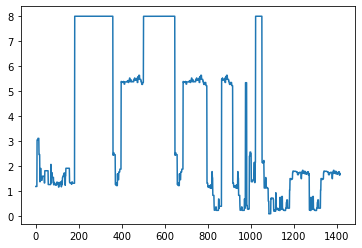

In [14]:
plt.plot(metric_value)
plt.show()

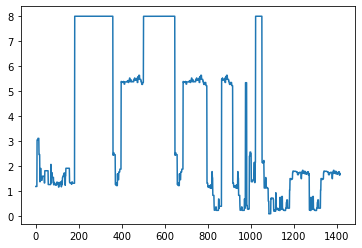

In [15]:
ano_path = "/home/hariprasad-packetai/work/dev/code/ml/mad/results/data/harilaptop-harilocal/harilaptop/system.cpu/system#cpu#total#pct/no_subject/no_subject|system.cpu|system#cpu#total#pct.csv"

ano_df = open_csv(ano_path)

ano_value = ano_df['value'].values

plt.plot(ano_value)

plt.show()

In [16]:
num_incidents = len(anom_incidents)
print(num_incidents)
sample_size = min(sample_size, num_incidents)
global_ind = range(num_incidents)
sample_ind = random.sample(global_ind, sample_size)

if num_incidents == sample_size:
    test_ind = sample_ind
else:
    test_ind = [x for x in global_ind if x not in sample_ind]

5


In [21]:
dev_val_vec = []
dur_val_vec = []

for cur_ind in sample_ind:
    cur_incident = anom_incidents[cur_ind]
    dev_val = max([x[0] for x in cur_incident])
    dur_val = len(cur_incident)
    dev_val_vec.append(dev_val)
    dur_val_vec.append(dur_val)

dev_model = pm.Model()
dur_model = pm.Model()
dur_model_exp = pm.Model()

with dev_model:
    lambda_est = pm.Uniform('lambda_est', lower=0, upper=10)
    y_exp = pm.Exponential('y_exp', lam=lambda_est, observed=dev_val_vec)

with dur_model:
    mu_est = pm.Uniform('mu_est', lower=0, upper=10)
    y_poiss = pm.Poisson('y_poiss', mu=mu_est, observed=dur_val_vec)

with dur_model_exp:
    lambda_dur = pm.Uniform('lambda_dur', lower=0, upper=10)
    y_exp_dur = pm.Exponential('y_exp_dur', lam=lambda_est, observed=dur_val_vec)
        
with dev_model:
    trace = pm.sample(2000, cores=1, chains=2, tune=1000)
    lambda_est_val = np.mean(trace['lambda_est'])
    
with dur_model:
    trace = pm.sample(2000, cores=1, chains=2, tune=1000)
    mu_est_val = np.mean(trace['mu_est'])

with dur_model_exp:
    trace = pm.sample(2000, cores=1, chains=2, tune=1000)
    lambda_dur_val = np.mean(trace['lambda_dur'])

print("Etimated lambda for deviation = {}, estimated mu for duration = {}, estimated lambda for duration = {}".format(lambda_est_val, mu_est_val, lambda_dur_val))

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [lambda_est]
Sampling chain 1, 0 divergences: 100%|██████████| 3000/3000 [00:02<00:00, 1342.01it/s]
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu_est]
Sampling chain 1, 1 divergences: 100%|██████████| 3000/3000 [00:02<00:00, 1244.44it/s]
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...


MissingInputError: Input 0 of the graph (indices start from 0), used to compute sigmoid(lambda_est_interval__), was not provided and not given a value. Use the Theano flag exception_verbosity='high', for more information on this error.

In [20]:
print(dev_val_vec)
print(dur_val_vec)
print(np.mean(dur_val_vec))

[2.5401, 8.0, 2.5401, 8.0, 8.0]
[10, 178, 9, 29, 139]
73.0


In [68]:
mu_est_val = min(1, mu_est_val)

tot_prob_vec = []
rel_score_vec = []

least_prob = 1.0

for cur_ind in test_ind:
    cur_incident = anom_incidents[cur_ind]
    dev_val = max([x[0] for x in cur_incident])
    dur_val = len(cur_incident)

    print("duration value {} deviation value {}".format(dur_val, dev_val))
    
    dur_prob = max(tol_val, (mu_est_val ** dur_val)*np.exp(-mu_est_val)/sp.special.factorial(dur_val))
    dev_prob = max(tol_val, (lambda_est_val)*np.exp(-dev_val*lambda_est_val))
    
    tot_prob = dev_prob*dur_prob

    print("duration prob {} deviation prob {} total prob {}".format(dur_prob, dev_prob, tot_prob))
    
    tot_prob_vec.append(tot_prob)
    
    if tot_prob < least_prob:
        least_prob = tot_prob

for tot_prob in tot_prob_vec:
    # rel_score_vec.append(100*(least_prob/tot_prob))
    rel_score_vec.append(100*(np.log(tot_prob)/np.log(least_prob)))

duration value 10 deviation value 2.5401
duration prob 1.0137771196302975e-07 deviation prob 0.12177019239182417 total prob 1.2344783489981067e-08
duration value 139 deviation value 8.0
duration prob 1e-128 deviation prob 0.03977407587517155 total prob 3.977407587517155e-130
duration value 9 deviation value 2.5401
duration prob 1.0137771196302974e-06 deviation prob 0.12177019239182417 total prob 1.2344783489981066e-07
duration value 29 deviation value 8.0
duration prob 4.1607028263361394e-32 deviation prob 0.03977407587517155 total prob 1.6548810990873434e-33
duration value 178 deviation value 8.0
duration prob 1e-128 deviation prob 0.03977407587517155 total prob 3.977407587517155e-130


In [69]:
anom_curves = []
gap_size = 10

filler_gap = [0 for _ in range(gap_size)]

anom_curves.extend(filler_gap)

for cur_ind in test_ind:
    cur_incident = anom_incidents[cur_ind]
    anom_curve = [x[0] for x in cur_incident]
    anom_curves.extend(anom_curve)
    anom_curves.extend(filler_gap)

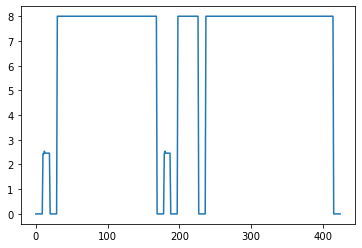

[6.111663123574443, 100.0, 5.3388679847986324, 25.333177663300336, 100.0]


In [70]:
plt.plot(anom_curves)
plt.show()
print(rel_score_vec)

In [57]:
mu_test = 19.92
lambda_test = 0.2049

dur_val = 20
dev_val = 8

tol_val = 1e-128

dur_prob = max(tol_val, (mu_test ** dur_val)*np.exp(-mu_test)/sp.special.factorial(dur_val))
dev_prob = max(tol_val, (lambda_test)*np.exp(-dev_val*lambda_test))

print("Duration probability {}, deviation probability {}".format(dur_prob, dev_prob))

Duration probability 0.08882106686728124, deviation probability 0.039778320596211864
